In [1]:
%load_ext autoreload
%autoreload 2

In [12]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import cobra

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# First, import the base kinGEMs package
import kinGEMs

# Import necessary functions from kinGEMs package
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, diagnose_infeasibility, relaxed_optimization, debug_enzyme_constraints_detailed
from kinGEMs.plots import plot_flux_distribution  # Assuming this function exists
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes

# Define paths
data_dir = "../data"
raw_data_dir = os.path.join(data_dir, "raw")
model_path = os.path.join(raw_data_dir, "e_coli_core.xml")
interim_data_dir = os.path.join(data_dir, "interim")
processed_data_dir = os.path.join(data_dir, "processed")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), 'results')
os.makedirs(results_dir, exist_ok=True)

In [3]:
# Step 1: Prepare model data (metabolite and sequence mapping)
print("Preparing model data...")
# Define output paths
substrates_output = os.path.join(interim_data_dir, "ecoli_substrates.csv")
sequences_output = os.path.join(interim_data_dir, "ecoli_sequences.csv")

# Prepare model data
irrev_model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism='E coli'
)

# display(substrate_df)
# display(sequences_df)

# Step 2: Merge substrate and sequence data
print("Merging substrate and sequence data...")
merged_data_output = os.path.join(interim_data_dir, "ecoli_merged_data.csv")
merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=irrev_model,
    output_path=merged_data_output
)

# display(merged_data)

### DEBUGGED UP TO THIS POINT - CHECK WHERE CPI-PRED KCAT VALUES ARE INCORPORATED 


Preparing model data...
Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-25
Loaded model with 95 reactions and 72 metabolites
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpeotj7zyx.lp
Reading time = 0.00 seconds
: 72 rows, 190 columns, 720 nonzeros
Number of reactions that are non-exchange:  75
Number of reactions that are exchange:  20
Number of reactions being added from non-exchange: 39
Number of reactions being added from exchange: 59
Converted to irreversible model with 154 reactions
Extracted 264 substrate-reaction pairs


c:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2\kinGEMs\dataset.py:215: DtypeWarning: Columns (4,10) have mixed types. Specify dtype option on import or set low_memory=False.
  SEED_comps = pd.read_csv(SEED_COMPOUNDS, sep='\t')
2025-05-13 11:36:47,996 - kinGEMs.dataset - INFO - There are 71 substrates in the GEM.
2025-05-13 11:36:48,098 - kinGEMs.dataset - INFO - -----------------------------
2025-05-13 11:36:48,098 - kinGEMs.dataset - INFO - Mapping substrate: atp_c
2025-05-13 11:36:48,136 - kinGEMs.dataset - INFO - BiGG Name: ATP C10H12N5O13P3
2025-05-13 11:36:48,183 - kinGEMs.dataset - INFO - SMILES found in MetaNetX: Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O)([O-])OP(=O)([O-])[O-])[C@@H](O)[C@H]1O
2025-05-13 11:36:48,183 - kinGEMs.dataset - INFO - -----------------------------
2025-05-13 11:36:48,183 - kinGEMs.dataset - INFO - Mapping substrate: f6p_c
2025-05-13 11:36:48,217 - kinGEMs.dataset - INFO - BiGG Name: D-Fructose 6-phosphate
2025-05-13 11:36:48,250 - kinGEMs.datas

Mapped metabolites to SMILES (264 found)


2025-05-13 11:36:57,921 - root - WARNING - No sequence found for gene s0001


Retrieved 136 protein sequences
Merging substrate and sequence data...


In [4]:
# Step 3: Create kcat data file from CPI-Pred fold predictions
print("Obtaining all kcat values for reactions from CPI-Pred...")
processed_data_output = os.path.join(processed_data_dir, "ecoli_processed_data.csv")
predictions_csv_path = os.path.join(CPIPred_data_dir, "X06A_kinGEMs_ecoli_core_predictions.csv")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

processed_data

Obtaining all kcat values for reactions from CPI-Pred...


,Reactions,Reaction_partners,CMPD_SMILES,BiGG Name,DB Name,Cleaned Substrate,Single_gene,GPR_rules,SEQ,kcat_x,...,pred_value_0,pred_value_1,pred_value_2,pred_value_3,pred_value_4,kcat_mean,kcat_std,kcat_cv,kcat_min,kcat_max
0,PFK,atp_c,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,ATP C10H12N5O13P3,ATP,atp,b3916,b3916 or b1723,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...,0.586212,...,1.575227,2.381814,0.918994,0.539413,1.595276,1.402145,0.707946,50.490222,0.539413,2.381814
1,PFK,atp_c,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,ATP C10H12N5O13P3,ATP,atp,b1723,b3916 or b1723,MVRIYTLTLAPSLDSATITPQIYPEGKLRCTAPVFEPGGGGINVAR...,0.746818,...,1.712434,1.314305,7.837847,4.029214,4.390350,3.856830,2.608914,67.643989,1.314305,7.837847
2,PFK,f6p_c,O=P([O-])([O-])OC[C@H]1O[C@](O)(CO)[C@@H](O)[C...,D-Fructose 6-phosphate,beta-D-Fructose 6-phosphate,f6p,b3916,b3916 or b1723,MIKKIGVLTSGGDAPGMNAAIRGVVRSALTEGLEVMGIYDGYLGLY...,0.705170,...,0.123544,1.851390,0.532669,0.274108,0.403308,0.637004,0.695623,109.202395,0.123544,1.851390
3,PFK,f6p_c,O=P([O-])([O-])OC[C@H]1O[C@](O)(CO)[C@@H](O)[C...,D-Fructose 6-phosphate,beta-D-Fructose 6-phosphate,f6p,b1723,b3916 or b1723,MVRIYTLTLAPSLDSATITPQIYPEGKLRCTAPVFEPGGGGINVAR...,0.080384,...,0.649286,1.299517,3.175090,1.616788,0.733416,1.494819,1.021150,68.312614,0.649286,3.175090
4,PFL,coa_c,CC(C)(CO[P](O)(=O)O[P](O)(=O)OC[C@H]1O[C@H]([C...,Coenzyme A,NaN,coa,b0902,((b0902 and b0903) and b2579) or (b0902 and b0...,MSVIGRIHSFESCGTVDGPGIRFITFFQGCLMRCLYCHNRDTWDTH...,0.827267,...,0.473469,0.401695,0.530946,0.993585,0.347434,0.549426,0.257882,46.936658,0.347434,0.993585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,MDH_reverse,oaa_c,O=C([O-])CC(=O)C(=O)[O-],Oxaloacetate,oxaloacetate,oaa,b3236,b3236,MKVAVLGAAGGIGQALALLLKTQLPSGSELSLYDIAPVTPGVAVDL...,0.387510,...,0.025550,0.030222,0.127074,0.024307,15.589225,3.159275,6.948689,219.945655,0.024307,15.589225
889,NH4t_reverse,nh4_c,[NH4+],Ammonium,NH4+,nh4,s0001,s0001 or b0451,None,0.343409,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
890,NH4t_reverse,nh4_c,[NH4+],Ammonium,NH4+,nh4,b0451,s0001 or b0451,MKIATIKTGLASLAMLPGLVMAAPAVADKADNAFMMICTALVLFMT...,0.200991,...,14.218272,22.738460,8.407519,17.392417,9.880905,14.527515,5.804486,39.955123,8.407519,22.738460
891,NH4t_reverse,nh4_c,[NH4+],Ammonium,NH4+,nh4,b0451,s0001 or b0451,MKIATIKTGLASLAMLPGLVMAAPAVADKADNAFMMICTALVLFMT...,0.200991,...,14.218272,22.738460,8.407519,17.392417,9.880905,14.527515,5.804486,39.955123,8.407519,22.738460


Running optimization...
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Results saved to: ../data\processed\FBA_BIOMASS_Ecoli_core_w_max_E0.125_Multi_Iso_Promis_Complex.csv
Optimization complete. Biomass flux: 0.01849337284014327
Plotting flux distribution...


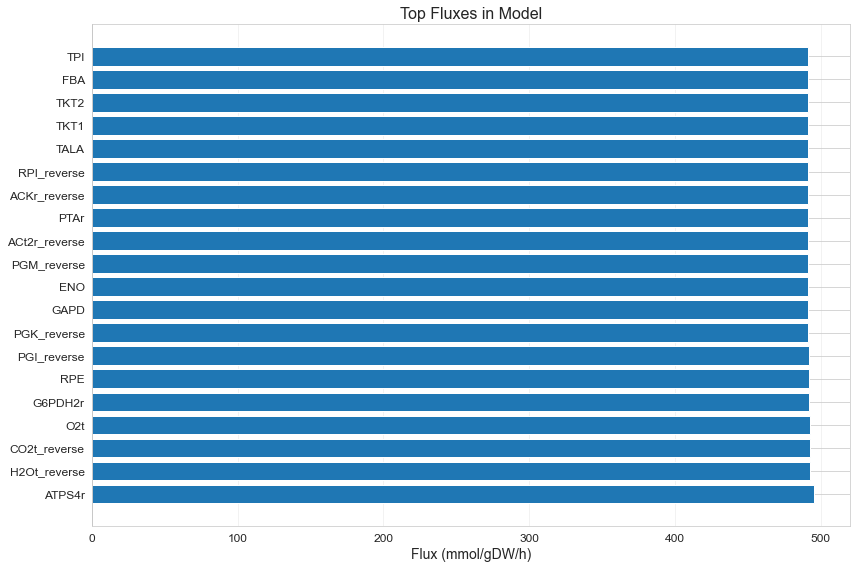

Results saved to: c:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2\notebooks\results\e_coli_flux_distribution.csv
Pipeline completed successfully!


In [5]:
# Step 4: Run optimization
print("Running optimization...")
# Set parameters for optimization
biomass_reaction = 'BIOMASS_Ecoli_core_w_GAM'  # Update with your biomass reaction ID
enzyme_upper_bound = 0.125  # gP/gDCW, enzyme fraction upper bound

# Run optimization
solution, flux_distribution, _, _ = run_optimization_with_dataframe(
    model=irrev_model,
    processed_df=processed_data,
    objective_reaction=biomass_reaction,
    enzyme_upper_bound=enzyme_upper_bound,
    enzyme_ratio=True, # Using enzyme fraction constraint,
    output_dir=processed_data_dir
)

# Fix: Check if solution is not None and print the value directly
if solution is not None:
    print(f"Optimization complete. Biomass flux: {solution}")
    
    # Step 5: Plot results
    print("Plotting flux distribution...")
    # Plot flux distribution
    fig = plot_flux_distribution(flux_distribution)
    plt.show()
    
    # Save results
    # Save the flux distribution
    output_file_path = os.path.join(results_dir, "e_coli_flux_distribution.csv")
    flux_distribution.to_csv(output_file_path, index=False)
    print(f"Results saved to: {output_file_path}")
    print("Pipeline completed successfully!")
else:
    print("Optimization failed - no solution found")

Running simulated annealing with 100 max iterations...
____________________
Simulated Annealing for tuning kcat function
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Initial working biomass: 0.018493372840142488
Iteration 1
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Change in biomass: 0.00000
Biomass with tuned kcats: 0.01849337284014439

Iteration 2
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Change in biomass: 0.00000
Biomass with tuned kcats: 0.018493372840144937

Iteration 3
Optimization completed successfully!
Total reaction-gene pairs: 227
Enzyme-constrained pairs: 0
Unconstrained pairs (missing data): 227
Change in biomass: 0.00000
Biomass with tuned kcats: 0.01849337284014315

Iteration 4
Optimization compl

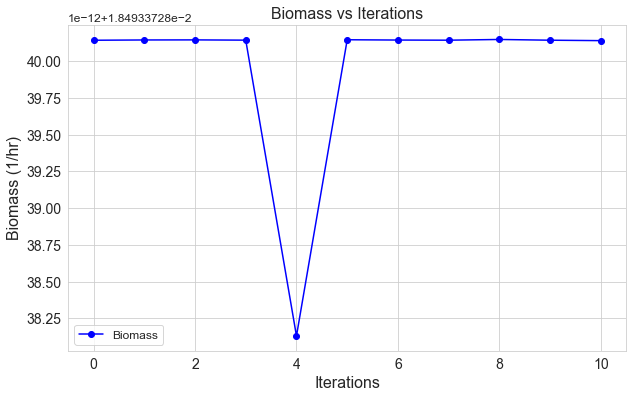

In [16]:
# Define output directory for tuning results
tuning_results_dir = os.path.join(results_dir, "tuning_results")
os.makedirs(tuning_results_dir, exist_ok=True)

# Set parameters for simulated annealing
temperature = 1.0
cooling_rate = 0.98
min_temperature = 0.01
max_iterations = 100  # Adjust for accuracy/speed tradeoff
max_unchanged_iterations = 10
change_threshold = 0.001

print(f"Running simulated annealing with {max_iterations} max iterations...")

# Run the updated simulated annealing process using processed_data
kcat_dict, df_enzyme_sorted, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=irrev_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Tuning complete. Final biomass: {biomasses[-1]}")
print(f"Improvement over initial: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.2f}%")
